In [ ]:
import pandas as pd

In [ ]:
data=pd.read_csv('Social_Network_Ads.csv')
data.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [ ]:
data.isnull().sum()

,0
Age,0
EstimatedSalary,0
Purchased,0


In [ ]:
X=data.iloc[:,0:2]
y=data.iloc[:,-1]

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

In [ ]:
X_train.head()

,Age,EstimatedSalary
92,26,15000
223,60,102000
234,38,112000
232,40,107000
377,42,53000


In [ ]:
X_test.head()

,Age,EstimatedSalary
132,30,87000
309,38,50000
341,35,75000
196,30,79000
246,35,50000


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled =  scaler.transform(X_test)

In [ ]:
scaler.mean_

array([3.78642857e+01, 6.98071429e+04])

In [ ]:
print(X_train.shape)

(280, 2)


In [ ]:
X_train_scaled

array([[-1.1631724 , -1.5849703 ],
       [ 2.17018137,  0.93098672],
       [ 0.0133054 ,  1.22017719],
       [ 0.20938504,  1.07558195],
       [ 0.40546467, -0.48604654],
       [-0.28081405, -0.31253226],
       [ 0.99370357, -0.8330751 ],
       [ 0.99370357,  1.8563962 ],
       [ 0.0133054 ,  1.24909623],
       [-0.86905295,  2.26126285],
       [-1.1631724 , -1.5849703 ],
       [ 2.17018137, -0.80415605],
       [-1.35925203, -1.46929411],
       [ 0.40546467,  2.2901819 ],
       [ 0.79762394,  0.75747245],
       [-0.96709276, -0.31253226],
       [ 0.11134522,  0.75747245],
       [-0.96709276,  0.55503912],
       [ 0.30742485,  0.06341534],
       [ 0.69958412, -1.26686079],
       [-0.47689368, -0.0233418 ],
       [-1.7514113 ,  0.3526058 ],
       [-0.67297331,  0.12125343],
       [ 0.40546467,  0.29476771],
       [-0.28081405,  0.06341534],
       [-0.47689368,  2.2901819 ],
       [ 0.20938504,  0.03449629],
       [ 1.28782302,  2.20342476],
       [ 0.79762394,

In [ ]:
X_train_scaled = pd.DataFrame(data=X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(data=X_test_scaled, columns=X_test.columns)

In [ ]:
X_train_scaled.head()

,Age,EstimatedSalary
0,-1.163172,-1.584970
1,2.170181,0.930987
2,0.013305,1.220177
3,0.209385,1.075582
4,0.405465,-0.486047


In [ ]:
import numpy as np
np.round(X_train.describe(), 1)

,Age,EstimatedSalary
count,280.0,280.0
mean,37.9,69807.1
std,10.2,34641.2
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,70500.0
75%,46.0,88000.0
max,60.0,150000.0


In [ ]:
np.round(X_train_scaled.describe(), 1)

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.8,0.5
max,2.2,2.3


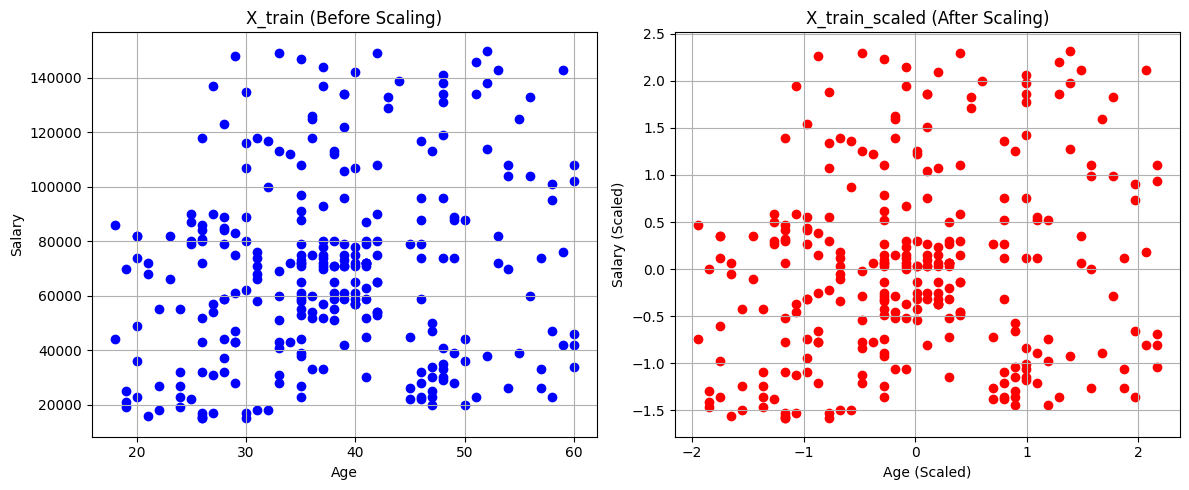

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# ---------------- BEFORE SCALING ----------------
plt.subplot(1, 2, 1)
plt.scatter(X_train['Age'], X_train['EstimatedSalary'], color='blue')
plt.title('X_train (Before Scaling)')
plt.xlabel('Age')
plt.ylabel('Salary')
plt.grid(True)

# ---------------- AFTER SCALING ----------------
plt.subplot(1, 2, 2)
plt.scatter(X_train_scaled['Age'], X_train_scaled['EstimatedSalary'], color='red')
plt.title('X_train_scaled (After Scaling)')
plt.xlabel('Age (Scaled)')
plt.ylabel('Salary (Scaled)')
plt.grid(True)

plt.tight_layout()
plt.show()

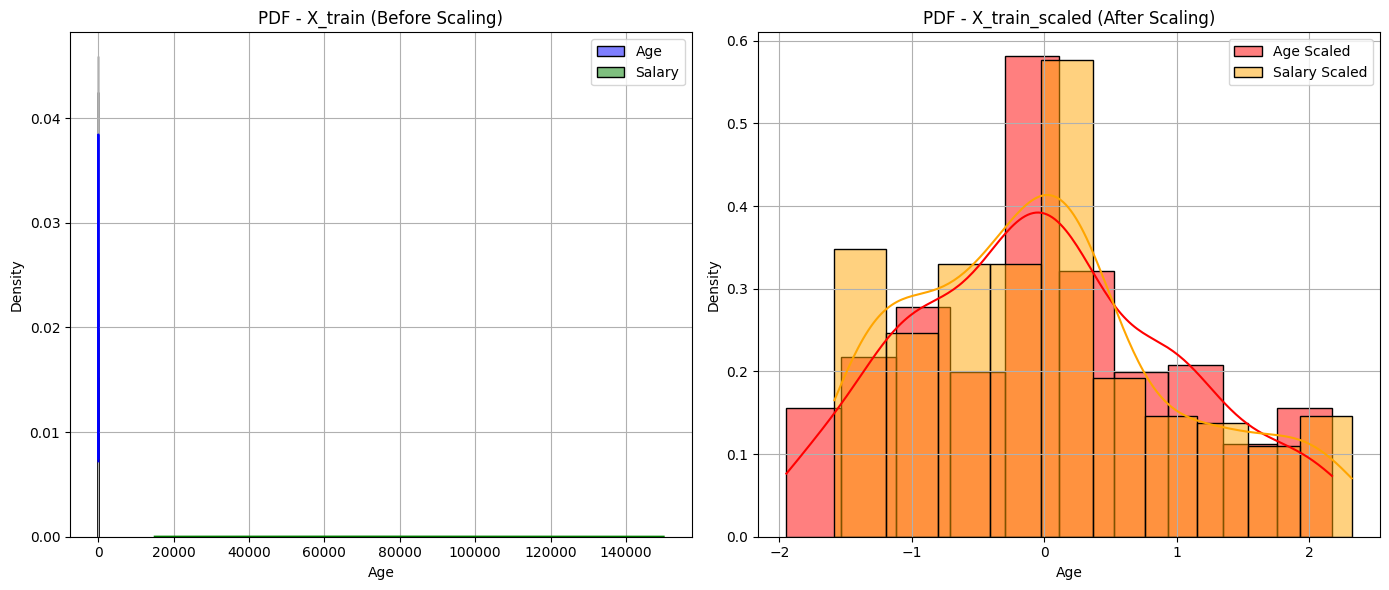

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,6))

# ---------------- BEFORE SCALING ----------------
plt.subplot(1, 2, 1)
sns.histplot(X_train['Age'], kde=True, stat="density", color='blue', label='Age')
sns.histplot(X_train['EstimatedSalary'], kde=True, stat="density", color='green', label='Salary')
plt.title('PDF - X_train (Before Scaling)')
plt.legend()
plt.grid(True)

# ---------------- AFTER SCALING ----------------
plt.subplot(1, 2, 2)
sns.histplot(X_train_scaled['Age'], kde=True, stat="density", color='red', label='Age Scaled')
sns.histplot(X_train_scaled['EstimatedSalary'], kde=True, stat="density", color='orange', label='Salary Scaled')
plt.title('PDF - X_train_scaled (After Scaling)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

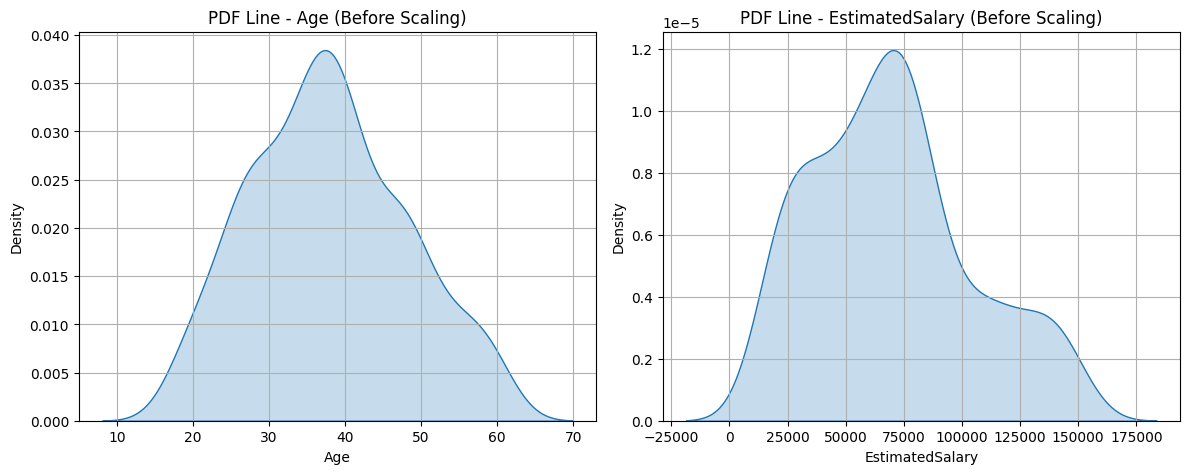

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,5))

# ---------------- AGE ----------------
plt.subplot(1, 2, 1)
sns.kdeplot(X_train['Age'], fill=True)
plt.title('PDF Line - Age (Before Scaling)')
plt.xlabel('Age')
plt.grid(True)

# ---------------- SALARY ----------------
plt.subplot(1, 2, 2)
sns.kdeplot(X_train['EstimatedSalary'], fill=True)
plt.title('PDF Line - EstimatedSalary (Before Scaling)')
plt.xlabel('EstimatedSalary')
plt.grid(True)

plt.tight_layout()
plt.show()

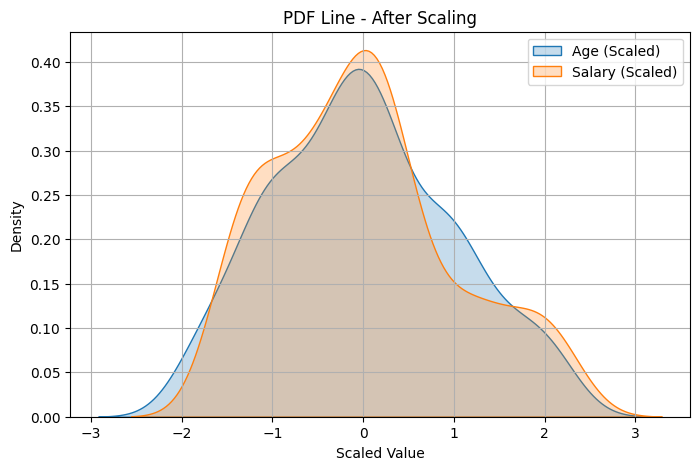

In [ ]:
plt.figure(figsize=(8,5))

sns.kdeplot(X_train_scaled['Age'], label='Age (Scaled)', fill=True)
sns.kdeplot(X_train_scaled['EstimatedSalary'], label='Salary (Scaled)', fill=True)

plt.title('PDF Line - After Scaling')
plt.xlabel('Scaled Value')
plt.ylabel('Density')

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr_scaled=LogisticRegression()

In [ ]:
lr.fit(X_train, y_train)
lr_scaled.fit(X_train_scaled, y_train)

LogisticRegression()

In [ ]:
y_pred=lr.predict(X_test)
y_pred_scaled=lr_scaled.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, y_pred))
print(accuracy_score(y_test, y_pred_scaled))

0.875
0.8666666666666667


In [ ]:
X

,Age,EstimatedSalary
0,19,19000
1,35,20000
2,26,43000
3,27,57000
4,19,76000
...,...,...
395,46,41000
396,51,23000
397,50,20000
398,36,33000
